In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
# DEPENDENCY: install the xlrd pip package to be able to read excel using pandas (pip install xlrd)
import warnings
warnings.filterwarnings('ignore')

import lib.processingTool as pt

In [3]:
static_raw = pd.read_csv("results/staticResults.csv", index_col=0)
optimal_raw = pd.read_csv("results/optimalResults.csv", index_col=0)
dynamic_raw = pd.read_csv("results/dynamicResults.csv", index_col=0)
annotations = pd.read_csv("results/annotations.csv")
filepaths, _, _, _ = pt.get_MVK_metadata()
dataset_size = len(filepaths)

static_raw["IoU"].mean()

0.24416075630887124

In [4]:
# filter out tests outside of the annotations (annotations are cleaned of duplicates, tests are not)
static = static_raw.merge(right=annotations, on=["author", "skippable", "annotation_id"], how="left").dropna(subset=['desc_short']).rename({"frame_idx_x": "frame_idx"}, axis=1)
static = static[static_raw.columns]
dynamic = dynamic_raw.merge(right=annotations, on=["author", "skippable", "annotation_id"], how="left").dropna(subset=['desc_short']).rename({"frame_idx_x": "frame_idx"}, axis=1)
dynamic = dynamic[dynamic_raw.columns]
optimal = optimal_raw.merge(right=annotations, on=["author", "skippable", "annotation_id"], how="left").dropna(subset=['desc_short']).rename({"frame_idx_x": "frame_idx"}, axis=1)
optimal = optimal[optimal_raw.columns]

In [5]:
def plot_cumulative(title: str, data: pd.DataFrame, key="dataset", key_label="Dataset", max_rank: int = 100, max_percentage: int = 40):
  fig, ax = plt.subplots()
  ax.set_xlabel("Rank")
  ax.set_ylabel("Annotation Percentage")
  hue = data[[key]].apply(lambda row: f"{row[key]}", axis=1)
  hue.name = key_label
  g = sns.ecdfplot(data=data, x="rank", hue=hue, stat="percent")
  g = g.set_title(title)
  ax.set_xlim(0, max_rank)
  ax.set_ylim(0, max_percentage)
  plt.show()

def get_9_piece_filter(data):
  return (data["kind"] == "9_piece_0") | (data["kind"] == "9_piece_5") | (data["kind"] == "9_piece_10") | (data["kind"] == "9_piece_15") | (data["kind"] == "9_piece_20") | (data["kind"] == "9_piece_25") | (data["kind"] == "9_piece_40")

def get_5_piece_filter(data):
  return (data["kind"] == "centerpiece_0") | (data["kind"] == "centerpiece_10") | (data["kind"] == "centerpiece_20") | (data["kind"] == "centerpiece_30")  | (data["kind"] == "centerpiece_40")



# Localization Report

This report will show annotation statistics and highlight the results of the static analysis.

It is currently work-in-progress, not all annotation files have been submitted yet. Find the submissions statistics below.

In [6]:
# annotation_count_data = static.drop_duplicates(["file_name", "annotation_id", "skippable"])
# skippable_data = annotation_count_data[annotation_count_data["skippable"] == True]
# unskippable_data = annotation_count_data[annotation_count_data["skippable"] == False]
# skippable_annotation_file_count = skippable_data['file_name'].nunique()
# unskippable_annotation_file_count = unskippable_data['file_name'].nunique()
# print(f"Number of skippable annotations/annotators: {skippable_data.shape[0]}/{skippable_annotation_file_count}")
# print(f"Number of unskippable annotations/annotators: {unskippable_data.shape[0]}/{unskippable_annotation_file_count}")

skippable_annotations = annotations[annotations["skippable"] == True]
skippable_authors = skippable_annotations["author"]
unskippable_annotations = annotations[annotations["skippable"] == False]
unskippable_authors = unskippable_annotations["author"]

print(f"Number of skippable annotations/annotators: {skippable_annotations.shape[0]}/{skippable_authors.nunique()}")
print(f"Number of unskippable annotations/annotators: {unskippable_annotations.shape[0]}/{unskippable_authors.nunique()}")

Number of skippable annotations/annotators: 486/12
Number of unskippable annotations/annotators: 255/12


## Annotations

Annotators were tasked to annotate the Marine Video Kit (MVK) dataset using a specialized program.
The program yielded annotation files for each user, which were in turn grouped into a dataset that can be seen below.

The dataset has 7 columns:
- _author_: Initials of the annotator.
- _skippable_: Whether the annotator could skip frames in the annotation program.
- _annotation\_id_: The serial number of the annotation inside an annotation file.
- _frame\_idx_: The annotated MVK frame identifier.
- _rect_: _x1_, _y1_, _x2_, _y2_ coordinates of the rectangle the annotator had to draw around an object of interest (OoI).
- _desc\_short_: A short description of the OoI.
- _desc\_long_: A longer description of the OoI.

In [7]:
annotations[annotations["author"] == "VK"].head()

,author,skippable,annotation_id,frame_idx,rect,desc_short,desc_long
390,VK,True,0,51668,"[531, 50, 621, 127]",a divers flipper,a blue divers flipper in water in front of a rock
391,VK,True,1,6643,"[34, 99, 236, 370]",diver with fishes,a diver with a silver oxygen tank behind a sch...
392,VK,True,2,6643,"[420, 146, 602, 296]",fishes,a light blue fish with smaller black and white...
393,VK,True,3,37353,"[257, 97, 472, 226]",two sharks,two sharks in dark blue water
394,VK,True,4,31653,"[326, 65, 481, 196]",two dark fish silhouettes,two dark fish silhouettes in water with a rock


Annotators were asked to provide 20 annotations without skipping and at least 20 with the option to skip frames.

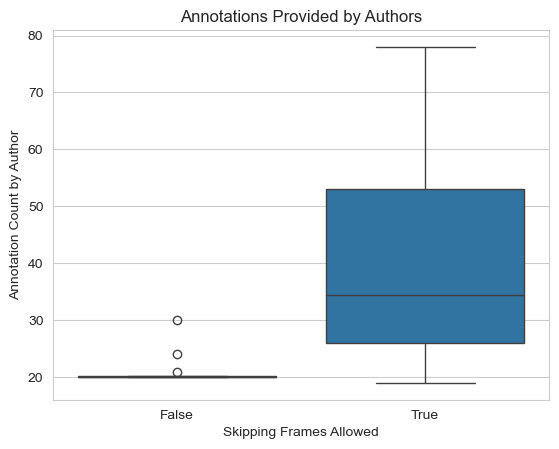

In [8]:
annotation_count_detail = annotations[["author", "skippable"]].groupby(["author", "skippable"]).size().reset_index().rename({0: "count"}, axis=1)

sns.set_style("whitegrid")
g = sns.boxplot(data=annotation_count_detail, x="skippable", y="count")
_ = g.yaxis.set_label_text("Annotation Count by Author")
_ = g.xaxis.set_label_text("Skipping Frames Allowed")
g = g.set_title("Annotations Provided by Authors")


Each object of interest had to be described with a short and long description.

Each respective text box had a text hint showing about how long the description should be.

The text hint for the short description was "_short description_" (17 characters) and for the long description "_a longer and more detailed description of the selected object_" (61 characters, 10 words).

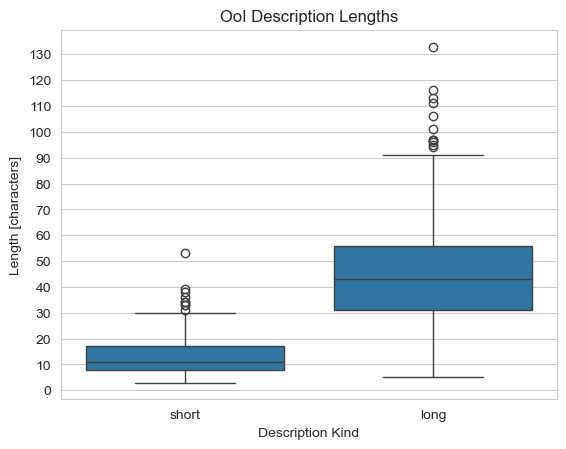

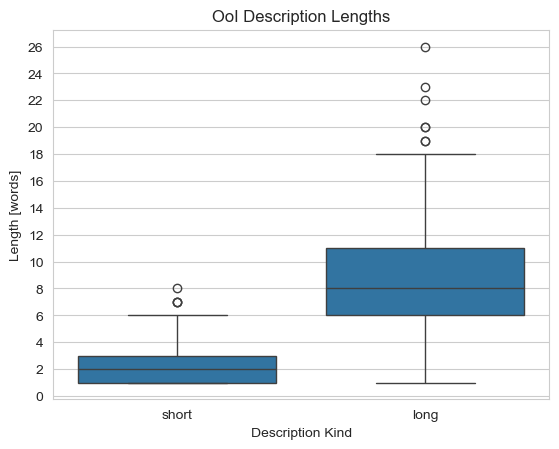

In [9]:
annotations_long = annotations.drop("desc_short", axis=1).rename(columns={"desc_long": "desc"})
annotations_long.insert(5, column="description_kind", value=["long"] * annotations.shape[0])
annotations_short = annotations.drop("desc_long", axis=1).rename(columns={"desc_short": "desc"})
annotations_short.insert(5, column="description_kind", value=["short"] * annotations.shape[0])
merged_annotations = pd.concat([annotations_short, annotations_long]).reset_index()
merged_annotations["length"] = [len(text) for text in merged_annotations["desc"]]
merged_annotations["words"] = [len(text.split()) for text in merged_annotations["desc"]]

g = sns.boxplot(data=merged_annotations, x="description_kind", y="length")
_ = g.yaxis.set_label_text("Length [characters]")
_ = g.xaxis.set_label_text("Description Kind")
g = g.set_title("OoI Description Lengths")
plt.yticks(ticks=list(range(0, 140, 10)))
plt.show()

g = sns.boxplot(data=merged_annotations, x="description_kind", y="words")
_ = g.yaxis.set_label_text("Length [words]")
_ = g.xaxis.set_label_text("Description Kind")
g = g.set_title("OoI Description Lengths")
_ = plt.yticks(ticks=list(range(0, 28, 2)))

## Static Analysis

The static analysis is conducted by dividing the MVK frames into grid segments and using the annotation rectangle position to select the segment with the highest intersection over union (IoU).
In that segment, the annotation descriptions are executed as user queries, simulating a localized video search engine request.
The request yields a list of all frames sorted by similarity to the query; the position (rank) of the actual annotated frame is stored as a performance indicator.

If the rank is low, it means that in the scope of the selected text-to-image model, the description and the described OoI are indeed similar.
Higher ranks mean that the model does not perceive the description and the OoI as related, which can either be the fault of the model (unknown concepts) or the annotator (generic/bad description, badly drawn rectangle, ...).

For the analysis, the segmentation grid used by the PraK tool in the 2025 VBS competition was used (labeled _centerpiece\_10_).
Additionally, a trivial grid consisting of a single whole-frame segment (labeled _whole_) was added as a baseline.

Each annotation took park in four tests differentiated by the model used (either the 2025 or 2024 PraK VBS model) and the grid type. 

The analysis yielded a dataset with 9 columns:
- _author_: Initials of the annotator.
- _annotation\_id_: The serial number of the annotation inside an annotation file.
- _skippable_: Whether the annotator could skip frames in the annotation program.
- _kind_: What kind of segmentation was used.
- _model\_year_: From what year is the model used for querying.
- _frame\_idx_: The annotated MVK frame identifier.
- _rank\_short_: The rank of the annotated frame when querying with the short description.
- _rank\_long_: The rank of the annotated frame when querying with the long description.
- _IoU_: The IoU with the selected segment.

In [10]:
static.head()

,author,skippable,annotation_id,perturbation_id,kind,model_year,frame_idx,rank_short,rank_long,IoU,pertubation_factor
0,AS,True,0,0,9_piece_0,2025,19294,31998,1622,0.188219,0.0
1,AS,True,1,0,9_piece_0,2025,70798,3,8,0.144993,0.0
3,AS,True,3,0,9_piece_0,2025,62757,24,34,0.112040,0.0
4,AS,True,4,0,9_piece_0,2025,25790,3652,312,0.283560,0.0
5,AS,True,5,0,9_piece_0,2025,25790,42518,33552,0.056778,0.0


In [11]:
ranks_long = static.drop("rank_short", axis=1).rename(columns={"rank_long": "rank"})
ranks_long.insert(5, "description_kind", ["long"] * static.shape[0])
ranks_short = static.drop("rank_long", axis=1).rename(columns={"rank_short": "rank"})
ranks_short.insert(5, "description_kind", ["short"] * static.shape[0])
merged_ranks = pd.concat([ranks_short, ranks_long])

def get_filtered_ranks(skippable: bool = None, kind: str = None, model_year: int = None, description_kind: str = None, pertubation_factor: float = None):
  selected_filters = []
  if skippable != None:
    selected_filters.append(merged_ranks["skippable"] == skippable)
  if kind != None:
    selected_filters.append(merged_ranks["kind"] == kind)
  if model_year != None:
    selected_filters.append(merged_ranks["model_year"] == model_year)
  if description_kind != None:
    selected_filters.append(merged_ranks["description_kind"] == description_kind)
  if pertubation_factor != None:
    selected_filters.append((merged_ranks["pertubation_factor"] > pertubation_factor - 0.001) & (merged_ranks["pertubation_factor"] < pertubation_factor + 0.001))
  
  if len(selected_filters) == 0:
    return merged_ranks

  filter = selected_filters[0]
  for i in range(1, len(selected_filters)):
    filter &= selected_filters[i]

  return merged_ranks[filter]

In [12]:
ranks_long = dynamic.drop("rank_short", axis=1).rename(columns={"rank_long": "rank"})
ranks_long.insert(5, "description_kind", ["long"] * dynamic.shape[0])
ranks_short = dynamic.drop("rank_long", axis=1).rename(columns={"rank_short": "rank"})
ranks_short.insert(5, "description_kind", ["short"] * dynamic.shape[0])
merged_ranks_dynamic = pd.concat([ranks_short, ranks_long])

def get_filtered_ranks_dynamic(skippable: bool = None, model_year: int = None, description_kind: str = None,):
  selected_filters = []
  if skippable != None:
    selected_filters.append(merged_ranks_dynamic["skippable"] == skippable)
  if model_year != None:
    selected_filters.append(merged_ranks_dynamic["model_year"] == model_year)
  if description_kind != None:
    selected_filters.append(merged_ranks_dynamic["description_kind"] == description_kind)
  
  if len(selected_filters) == 0:
    return merged_ranks_dynamic

  filter = selected_filters[0]
  for i in range(1, len(selected_filters)):
    filter &= selected_filters[i]

  return merged_ranks_dynamic[filter]

There is a total of four boolean parameters used to filter the static dataset:
- Model year.
- Segmentation kind.
- Whether the user could skip during annotation.
- Whether the short or long description is used.

Each cumulative graph line below is described by a specific combination of these four parameters.

### Model Strength and Description Length

These graphs depict unskippable annotations with the _centerpiece\_10_ segmentation.

It can be seen that the longer descriptions (green and red lines) generally outperform shorter ones.
If we consider only the top ranks (the second graph), both models perform more or less equally, as long as the longer descriptions are used.
This starts to deviate at around rank 700.
Later on, the 2025 model outperforms the 2024 model considerably.

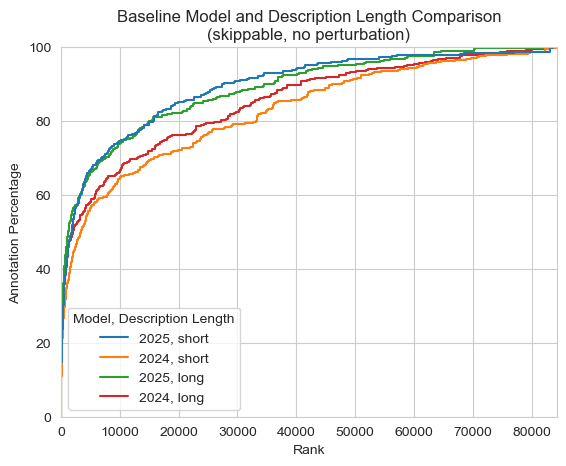

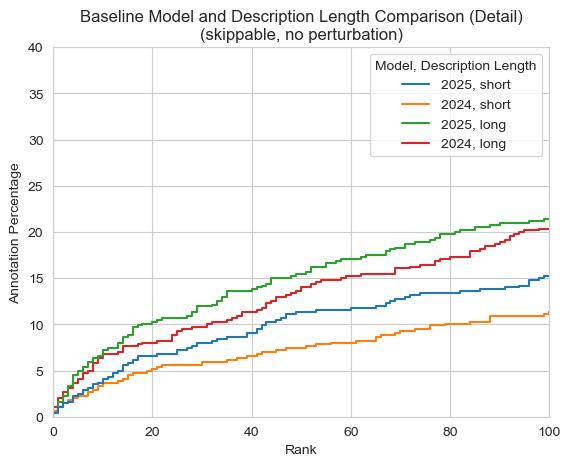

In [13]:
filtered = get_filtered_ranks(skippable=True, kind="whole", pertubation_factor=0.0)

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, dataset_size)
ax.set_ylim(0, 100)
g = g.set_title("Baseline Model and Description Length Comparison\n(skippable, no perturbation)")

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)
g = g.set_title("Baseline Model and Description Length Comparison (Detail)\n(skippable, no perturbation)")


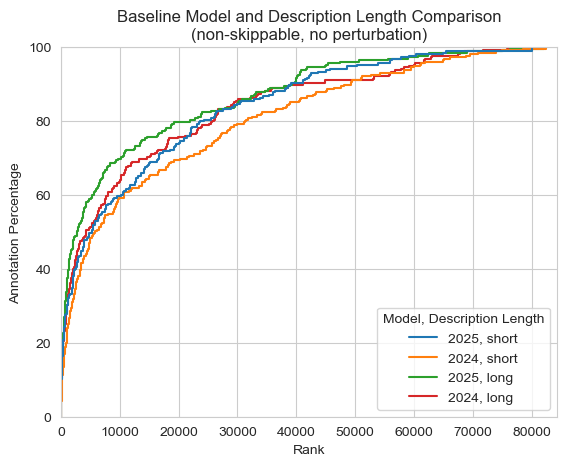

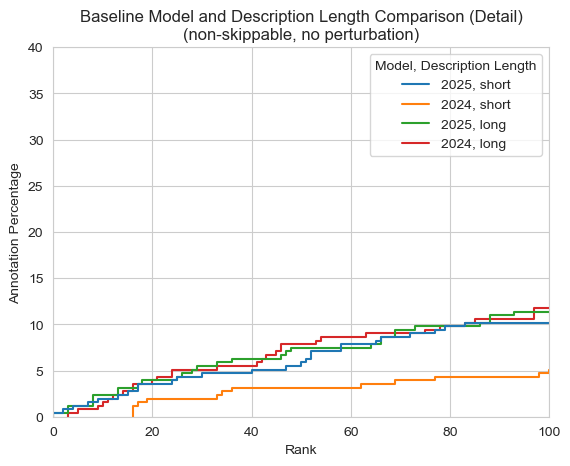

In [14]:
filtered = get_filtered_ranks(skippable=False, kind="whole", pertubation_factor=0.0)

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, dataset_size)
ax.set_ylim(0, 100)
g = g.set_title("Baseline Model and Description Length Comparison\n(non-skippable, no perturbation)")

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)
g = g.set_title("Baseline Model and Description Length Comparison (Detail)\n(non-skippable, no perturbation)")


### Influence of Segmentation

The following graphs show the influence of segmentation.

Up to around rank 70, the performance seems identical, but later on the segmentation helps considerably.
This could imply that good descriptions that in turn produce good queries do not need the help of segmentation to rank well.
On the other hand, segmentation seems to help when the descriptions is too generic.

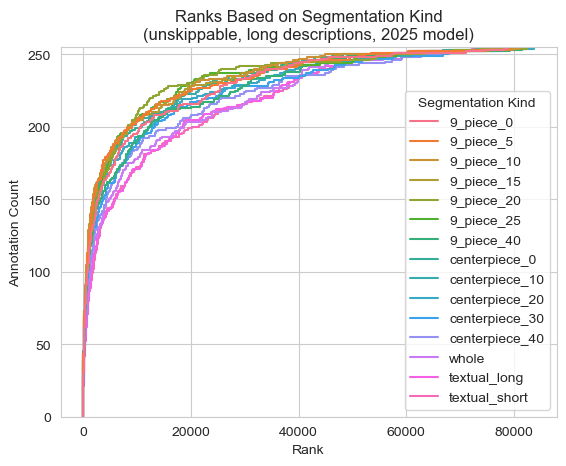

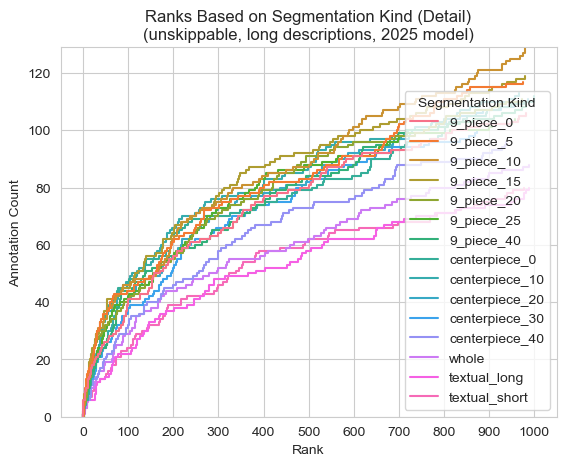

In [15]:
filtered = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", pertubation_factor=0)

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
hue = filtered[["kind"]].apply(lambda row: f"{row.kind}", axis=1)
hue.name = "Segmentation Kind"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="count")
g = g.set_title("Ranks Based on Segmentation Kind\n(unskippable, long descriptions, 2025 model)")
plt.show()


fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
filtered_top_1000 = filtered[filtered["rank"] < 1000]
hue = filtered_top_1000[["kind"]].apply(lambda row: f"{row.kind}", axis=1)
hue.name = "Segmentation Kind"
g = sns.ecdfplot(data=filtered_top_1000, x="rank", hue=hue, stat="count")
g.xaxis.set_major_locator(ticker.MultipleLocator(100))
g = g.set_title("Ranks Based on Segmentation Kind (Detail)\n(unskippable, long descriptions, 2025 model)")

### Annotation Quality

The following graph compares individual annotators among themselves.
Its purpose is to check whether there are anomalous annotators whose descriptions perform either too well or too bad, which could in turn influence the graphs above.

Because each annotator produced a different number of annotations, only the first 20 annotations are considered.

However, the graph does not show any anomalous behavior.
The rank discrepancy is likely due to the random nature of the frames presented to the annotators, where some could mostly see empty water and others animals. 

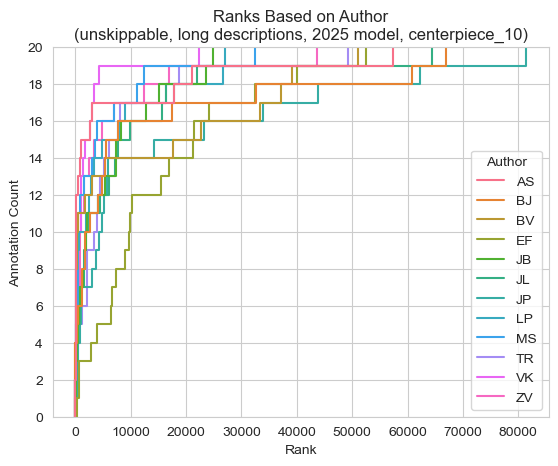

In [16]:
filtered = (get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="centerpiece_10")
  .groupby("author")
  .head(20))

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
hue = filtered[["author"]].apply(lambda row: f"{row.author}", axis=1)
hue.name = "Author"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="count")
g.yaxis.set_major_locator(ticker.MultipleLocator(2))
g = g.set_title("Ranks Based on Author\n(unskippable, long descriptions, 2025 model, centerpiece_10)")


An identical graph was produced, but now for skippable annotations.

It looks like users that ranked worse in the unskippable comparison fared better here and vice versa, implying that their performance discrepancy is likely due to luck.

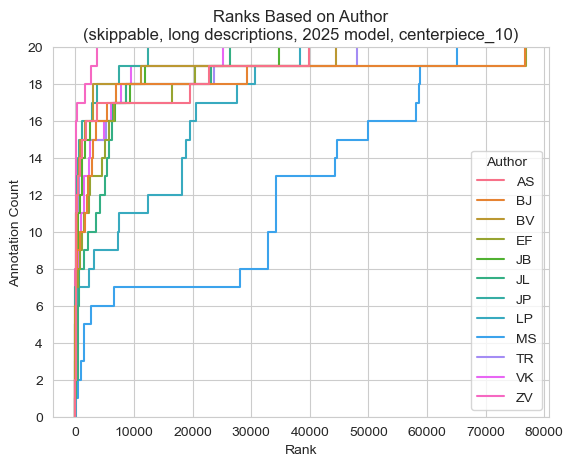

In [17]:
filtered = (get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind="centerpiece_10")
  .groupby("author")
  .head(20))

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
hue = filtered[["author"]].apply(lambda row: f"{row.author}", axis=1)
hue.name = "Author"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="count")
g.yaxis.set_major_locator(ticker.MultipleLocator(2))
g = g.set_title("Ranks Based on Author\n(skippable, long descriptions, 2025 model, centerpiece_10)")


### Rank and IoU Correlation

A hypothesis was made that higher IoU implies a better rank due to the greater amount of relevant visual data to the described object in the selected segment when compared to other segments.

In [18]:
filtered = get_filtered_ranks()

rank_IoU_corr = filtered["rank"].corr(filtered["IoU"])
print(f"Rank and IoU correlation: {rank_IoU_corr}")

Rank and IoU correlation: -0.12381147299879669


Although the correlation is negative as expected (higher IoU means a lower, better rank), it is too low to be significant.

## Theoretical Analysis

In [19]:
optimal.head()

,author,skippable,annotation_id,box_enlargements,model_year,frame_idx,rank_short,rank_long,area
0,AS,False,0,0,2025,22407,4,21,33292
1,AS,False,1,0,2025,54444,40,78,5586
2,AS,False,2,0,2025,78972,46,86,11808
3,AS,False,3,0,2025,618,24,95,16461
4,AS,False,4,0,2025,57433,320,9,1872


In [20]:
ranks_long_optimal = optimal.drop("rank_short", axis=1).rename(columns={"rank_long": "rank"})
ranks_long_optimal.insert(5, "description_kind", ["long"] * optimal.shape[0])
ranks_short_optimal = optimal.drop("rank_long", axis=1).rename(columns={"rank_short": "rank"})
ranks_short_optimal.insert(5, "description_kind", ["short"] * optimal.shape[0])
merged_ranks_optimal = pd.concat([ranks_short_optimal, ranks_long_optimal])

def get_filtered_ranks_optimal(skippable: bool = None, box_enlargements: int = None, model_year: int = None, description_kind: str = None):
  selected_filters = []
  if skippable != None:
    selected_filters.append(merged_ranks_optimal["skippable"] == skippable)
  if box_enlargements != None:
    selected_filters.append(merged_ranks_optimal["box_enlargements"] == box_enlargements)
  if model_year != None:
    selected_filters.append(merged_ranks_optimal["model_year"] == model_year)
  if description_kind != None:
    selected_filters.append(merged_ranks_optimal["description_kind"] == description_kind)
  
  if len(selected_filters) == 0:
    return merged_ranks_optimal

  filter = selected_filters[0]
  for i in range(1, len(selected_filters)):
    filter &= selected_filters[i]

  return merged_ranks_optimal[filter]

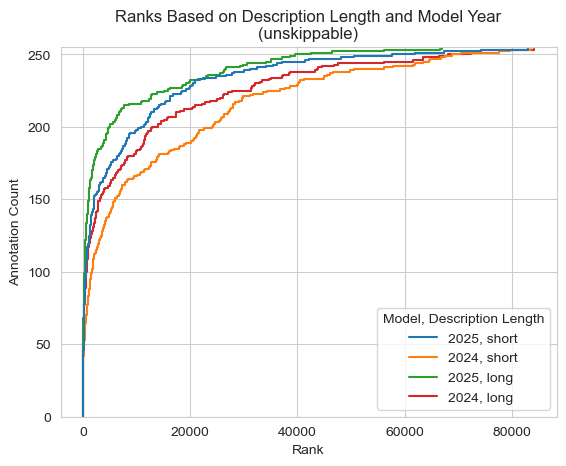

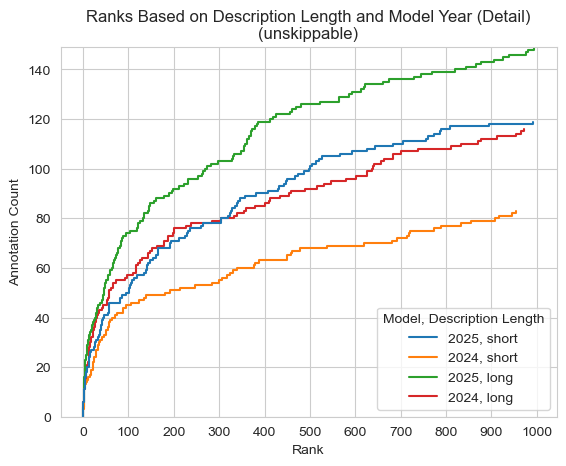

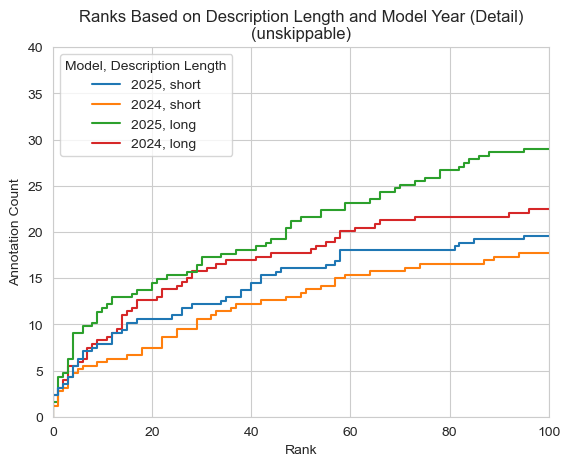

In [21]:
filtered = get_filtered_ranks_optimal(skippable=False, box_enlargements=0)

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="count")
g = g.set_title("Ranks Based on Description Length and Model Year\n(unskippable)")
plt.show()


fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
filtered_top_1000 = filtered[filtered["rank"] < 1000]
hue = filtered_top_1000[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered_top_1000, x="rank", hue=hue, stat="count")
g.xaxis.set_major_locator(ticker.MultipleLocator(100))
g = g.set_title("Ranks Based on Description Length and Model Year (Detail)\n(unskippable)")

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Count")
hue = filtered[["model_year", "description_kind"]].apply(lambda row: f"{row.model_year}, {row.description_kind}", axis=1)
hue.name = "Model, Description Length"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)
g = g.set_title("Ranks Based on Description Length and Model Year (Detail)\n(unskippable)")


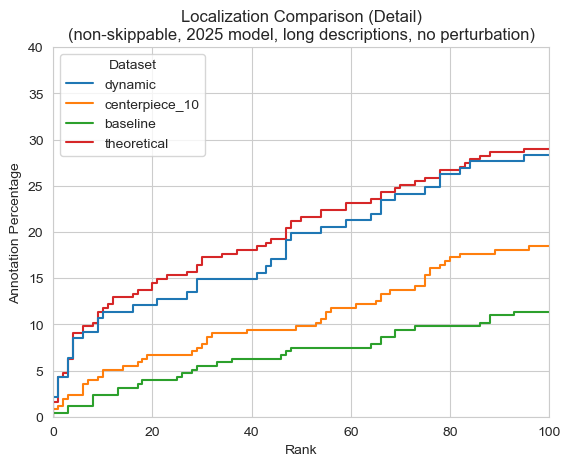

In [22]:
filtered_static = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="centerpiece_10", pertubation_factor=0)
filtered_baseline = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="whole")
filtered_optimal = get_filtered_ranks_optimal(skippable=False, model_year=2025, description_kind="long", box_enlargements=0)

#TODO: change once there is more dynamic data
filtered_dynamic = dynamic

# remove rows from the @filtered_dataset so that it matches the @filtered_optimal dataset
def confine_to_annotation_ids(filtered_dataset, filtered_optimal):
  # not all authors were processed
  unique_authors = filtered_optimal["author"].unique()
  filtered_dataset = filtered_dataset[filtered_dataset["author"].isin(unique_authors)]

  dataset_fragments = []
  for author in unique_authors:
    dataset_fragment = filtered_dataset[filtered_dataset["author"] == author]
    optimal_fragment = filtered_optimal[filtered_optimal["author"] == author]
    ids = optimal_fragment["annotation_id"]
    dataset_fragment = dataset_fragment[dataset_fragment["annotation_id"].isin(ids)]
    dataset_fragments.append(dataset_fragment)
  return pd.concat(dataset_fragments)

filtered_static = confine_to_annotation_ids(filtered_static, filtered_optimal)
filtered_baseline = confine_to_annotation_ids(filtered_baseline, filtered_optimal)
filtered_dynamic = confine_to_annotation_ids(filtered_dynamic, filtered_optimal)

# join them together
filtered_static.insert(0, "dataset", ["centerpiece_10"] * filtered_static.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered_optimal.insert(0, "dataset", ["theoretical"] * filtered_optimal.shape[0])
filtered_dynamic.insert(0, "dataset", ["dynamic"] * filtered_dynamic.shape[0])
filtered = pd.concat([filtered_dynamic, filtered_static, filtered_baseline, filtered_optimal])

plot_cumulative("Localization Comparison (Detail)\n(non-skippable, 2025 model, long descriptions, no perturbation)", filtered)


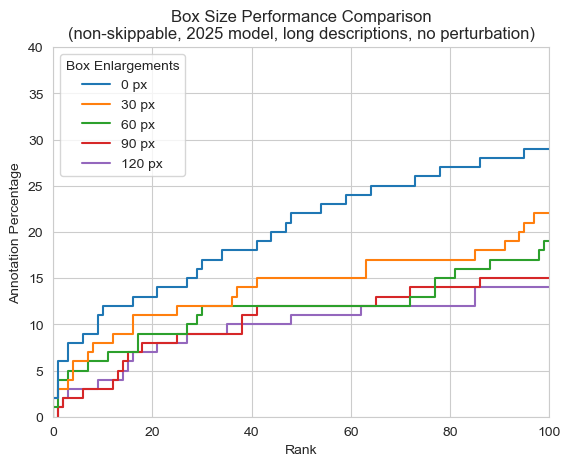

In [63]:
filtered = get_filtered_ranks_optimal(skippable=False, model_year=2025, description_kind="long")
filtered_static = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="whole")
filtered_static
# filtered.reset_index()
# area_incs = []
# for index, row in filtered.iterrows():
#   filter = (filtered["author"] == row["author"]) & (filtered["skippable"] == row["skippable"]) & (filtered["annotation_id"] == row["annotation_id"])
#   base = filtered[filter & (filtered["box_enlargements"] == 0)]
#   area_incs.append(int(row.area) / int(base.area))
# filtered.insert(0, "area_inc", area_incs)

filtered = pd.concat([
  filtered[filtered.box_enlargements == 0][:100],
  filtered[filtered.box_enlargements == 1][:100],
  filtered[filtered.box_enlargements == 2][:100],
  filtered[filtered.box_enlargements == 3][:100],
  filtered[filtered.box_enlargements == 4][:100],
])

fig, ax = plt.subplots()
ax.set_xlabel("Rank")
ax.set_ylabel("Annotation Percentage")
hue = filtered[["box_enlargements"]].apply(lambda row: f"{row.box_enlargements * 30} px", axis=1)
hue.name = "Box Enlargements"
g = sns.ecdfplot(data=filtered, x="rank", hue=hue, stat="percent")
g = g.set_title("Box Size Performance Comparison\n(non-skippable, 2025 model, long descriptions, no perturbation)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 40)
plt.show()


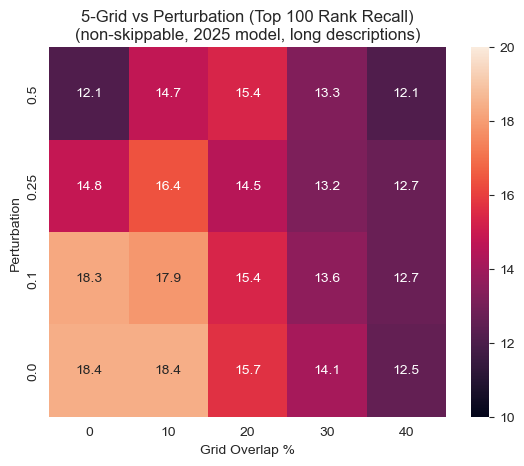

In [24]:
grids = ["centerpiece_0", "centerpiece_10", "centerpiece_20", "centerpiece_30", "centerpiece_40"]
pertubation_factors = [0, 0.1, 0.25, 0.5]

rows = []
for grid in grids:
  for factor in pertubation_factors:
    filtered = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind=grid, pertubation_factor=factor)
    top_100_count = len(filtered[filtered["rank"] < 100])
    score = top_100_count / unskippable_annotations.shape[0] * 100
    if factor > 0:
      score /= 5
    rows.append({
      "grid": grid.split("_")[1],
      "pertubation": factor,
      "score": score,
    })

heatmap_df = pd.DataFrame(rows)
pivoted = heatmap_df.pivot(index="pertubation", columns="grid", values="score")
pivoted = pivoted.reindex(index=pivoted.index[::-1])



g = sns.heatmap(pivoted, vmin=10, vmax=20, annot=True, fmt=".1f")
g = g.set(xlabel="Grid Overlap %", ylabel="Perturbation", title="5-Grid vs Perturbation (Top 100 Rank Recall)\n(non-skippable, 2025 model, long descriptions)")

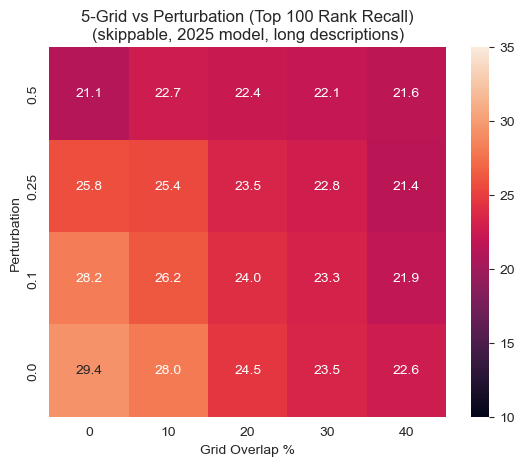

In [25]:
grids = ["centerpiece_0", "centerpiece_10", "centerpiece_20", "centerpiece_30", "centerpiece_40"]
pertubation_factors = [0, 0.1, 0.25, 0.5]

rows = []
for grid in grids:
  for factor in pertubation_factors:
    filtered = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind=grid, pertubation_factor=factor)
    top_100_count = len(filtered[filtered["rank"] < 100])
    score = top_100_count / skippable_annotations.shape[0] * 100
    if factor > 0:
      score /= 5
    rows.append({
      "grid": grid.split("_")[1],
      "pertubation": factor,
      "score": score,
    })

heatmap_df = pd.DataFrame(rows)
pivoted = heatmap_df.pivot(index="pertubation", columns="grid", values="score")
pivoted = pivoted.reindex(index=pivoted.index[::-1])



g = sns.heatmap(pivoted, vmin=10, vmax=35, annot=True, fmt=".1f")
g = g.set(xlabel="Grid Overlap %", ylabel="Perturbation", title="5-Grid vs Perturbation (Top 100 Rank Recall)\n(skippable, 2025 model, long descriptions)")



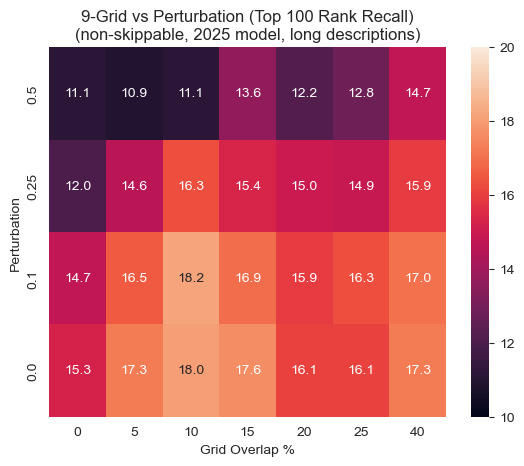

In [26]:
grids = ["9_piece_0", "9_piece_5", "9_piece_10", "9_piece_15", "9_piece_20", "9_piece_25",  "9_piece_40"]
pertubation_factors = [0, 0.1, 0.25, 0.5]

rows = []
for grid in grids:
  for factor in pertubation_factors:
    filtered = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind=grid, pertubation_factor=factor)
    top_100_count = len(filtered[filtered["rank"] < 100])
    score = top_100_count / unskippable_annotations.shape[0] * 100
    if factor > 0:
      score /= 5
    rows.append({
      "grid": grid.split("_")[2],
      "pertubation": factor,
      "score": score,
    })

heatmap_df = pd.DataFrame(rows)
pivoted = heatmap_df.pivot(index="pertubation", columns="grid", values="score")
pivoted = pivoted.reindex(index=pivoted.index[::-1])
pivoted = pivoted[['0', '5', '10', '15', '20', '25', '40']]

g = sns.heatmap(pivoted, vmin=10, vmax=20, annot=True, fmt=".1f")
g = g.set(xlabel="Grid Overlap %", ylabel="Perturbation", title="9-Grid vs Perturbation (Top 100 Rank Recall)\n(non-skippable, 2025 model, long descriptions)")



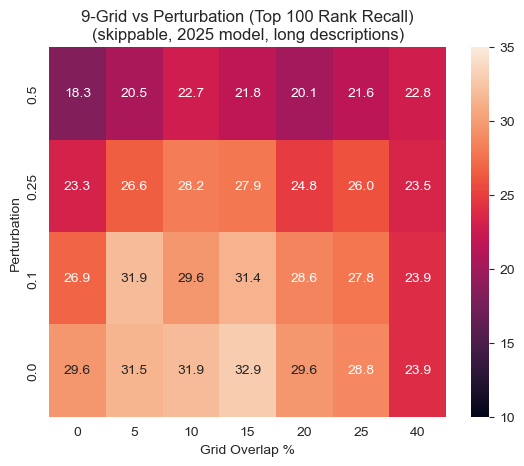

In [27]:
grids = ["9_piece_0", "9_piece_5", "9_piece_10", "9_piece_15", "9_piece_20", "9_piece_25",  "9_piece_40"]
pertubation_factors = [0, 0.1, 0.25, 0.5]

rows = []
for grid in grids:
  for factor in pertubation_factors:
    filtered = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind=grid, pertubation_factor=factor)
    top_100_count = len(filtered[filtered["rank"] < 100])
    score = top_100_count / skippable_annotations.shape[0] * 100
    if factor > 0:
      score /= 5
    rows.append({
      "grid": grid.split("_")[2],
      "pertubation": factor,
      "score": score,
    })

heatmap_df = pd.DataFrame(rows)
pivoted = heatmap_df.pivot(index="pertubation", columns="grid", values="score")
pivoted = pivoted.reindex(index=pivoted.index[::-1])
pivoted = pivoted[['0', '5', '10', '15', '20', '25', '40']]

g = sns.heatmap(pivoted, vmin=10, vmax=35, annot=True, fmt=".1f")
g = g.set(xlabel="Grid Overlap %", ylabel="Perturbation", title="9-Grid vs Perturbation (Top 100 Rank Recall)\n(skippable, 2025 model, long descriptions)")

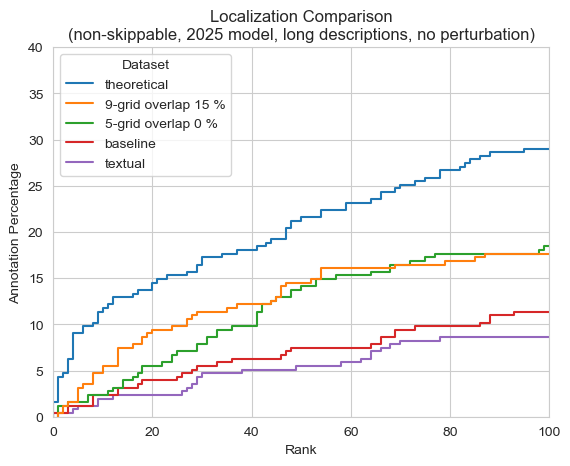

In [28]:
filtered_static = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="centerpiece_0", pertubation_factor=0)
filtered_9_grid = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="9_piece_15", pertubation_factor=0)
filtered_textual = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="textual_long", pertubation_factor=0)
filtered_baseline = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="whole")
filtered_optimal = get_filtered_ranks_optimal(skippable=False, model_year=2025, description_kind="long", box_enlargements=0)


# remove rows from the @filtered_dataset so that it matches the @filtered_optimal dataset
def confine_to_annotation_ids(filtered_dataset, filtered_optimal):
  # not all authors were processed
  unique_authors = filtered_optimal["author"].unique()
  filtered_dataset = filtered_dataset[filtered_dataset["author"].isin(unique_authors)]

  dataset_fragments = []
  for author in unique_authors:
    dataset_fragment = filtered_dataset[filtered_dataset["author"] == author]
    optimal_fragment = filtered_optimal[filtered_optimal["author"] == author]
    ids = optimal_fragment["annotation_id"]
    dataset_fragment = dataset_fragment[dataset_fragment["annotation_id"].isin(ids)]
    dataset_fragments.append(dataset_fragment)
  return pd.concat(dataset_fragments)

filtered_static = confine_to_annotation_ids(filtered_static, filtered_optimal)
filtered_9_grid = confine_to_annotation_ids(filtered_9_grid, filtered_optimal)
filtered_textual = confine_to_annotation_ids(filtered_textual, filtered_optimal)
filtered_baseline = confine_to_annotation_ids(filtered_baseline, filtered_optimal)

# join them together
filtered_static.insert(0, "dataset", ["5-grid overlap 0 %"] * filtered_static.shape[0])
filtered_9_grid.insert(0, "dataset", ["9-grid overlap 15 %"] * filtered_9_grid.shape[0])
filtered_textual.insert(0, "dataset", ["textual"] * filtered_textual.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered_optimal.insert(0, "dataset", ["theoretical"] * filtered_optimal.shape[0])
filtered = pd.concat([filtered_optimal, filtered_9_grid, filtered_static, filtered_baseline, filtered_textual])

plot_cumulative("Localization Comparison\n(non-skippable, 2025 model, long descriptions, no perturbation)", filtered)


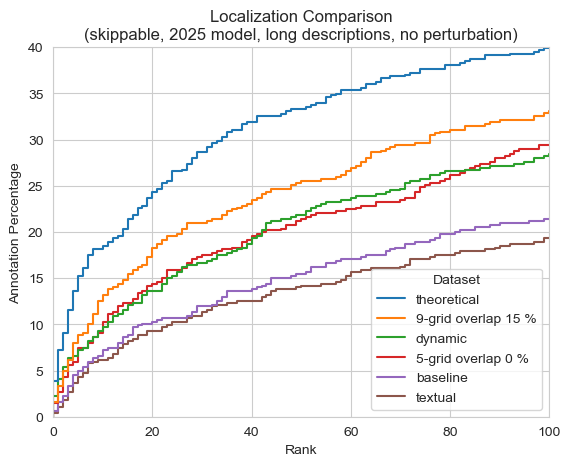

In [48]:
filtered_static = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind="centerpiece_0", pertubation_factor=0)
filtered_9_grid = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind="9_piece_15", pertubation_factor=0)
filtered_textual = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind="textual_long", pertubation_factor=0)
filtered_baseline = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", kind="whole")
filtered_optimal = get_filtered_ranks_optimal(skippable=True, model_year=2025, description_kind="long", box_enlargements=0)
filtered_dynamic = get_filtered_ranks_dynamic(skippable=True, model_year=2025, description_kind="long")


# remove rows from the @filtered_dataset so that it matches the @filtered_optimal dataset
def confine_to_annotation_ids(filtered_dataset, filtered_optimal):
  # not all authors were processed
  unique_authors = filtered_optimal["author"].unique()
  filtered_dataset = filtered_dataset[filtered_dataset["author"].isin(unique_authors)]

  dataset_fragments = []
  for author in unique_authors:
    dataset_fragment = filtered_dataset[filtered_dataset["author"] == author]
    optimal_fragment = filtered_optimal[filtered_optimal["author"] == author]
    ids = optimal_fragment["annotation_id"]
    dataset_fragment = dataset_fragment[dataset_fragment["annotation_id"].isin(ids)]
    dataset_fragments.append(dataset_fragment)
  return pd.concat(dataset_fragments)

filtered_static = confine_to_annotation_ids(filtered_static, filtered_optimal)
filtered_9_grid = confine_to_annotation_ids(filtered_9_grid, filtered_optimal)
filtered_textual = confine_to_annotation_ids(filtered_textual, filtered_optimal)
filtered_baseline = confine_to_annotation_ids(filtered_baseline, filtered_optimal)
filtered_dynamic = confine_to_annotation_ids(filtered_dynamic, filtered_optimal)

# join them together
filtered_static.insert(0, "dataset", ["5-grid overlap 0 %"] * filtered_static.shape[0])
filtered_9_grid.insert(0, "dataset", ["9-grid overlap 15 %"] * filtered_9_grid.shape[0])
filtered_textual.insert(0, "dataset", ["textual"] * filtered_textual.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered_optimal.insert(0, "dataset", ["theoretical"] * filtered_optimal.shape[0])
filtered_dynamic.insert(0, "dataset", ["dynamic"] * filtered_dynamic.shape[0])
filtered = pd.concat([filtered_optimal, filtered_9_grid, filtered_dynamic, filtered_static, filtered_baseline, filtered_textual])

plot_cumulative("Localization Comparison\n(skippable, 2025 model, long descriptions, no perturbation)", filtered)


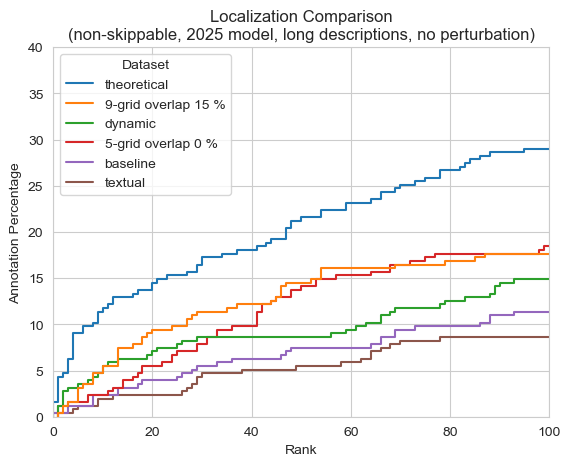

In [50]:
filtered_static = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="centerpiece_0", pertubation_factor=0)
filtered_9_grid = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="9_piece_15", pertubation_factor=0)
filtered_textual = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="textual_long", pertubation_factor=0)
filtered_baseline = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", kind="whole")
filtered_optimal = get_filtered_ranks_optimal(skippable=False, model_year=2025, description_kind="long", box_enlargements=0)
filtered_dynamic = get_filtered_ranks_dynamic(skippable=False, model_year=2025, description_kind="long")


# remove rows from the @filtered_dataset so that it matches the @filtered_optimal dataset
def confine_to_annotation_ids(filtered_dataset, filtered_optimal):
  # not all authors were processed
  unique_authors = filtered_optimal["author"].unique()
  filtered_dataset = filtered_dataset[filtered_dataset["author"].isin(unique_authors)]

  dataset_fragments = []
  for author in unique_authors:
    dataset_fragment = filtered_dataset[filtered_dataset["author"] == author]
    optimal_fragment = filtered_optimal[filtered_optimal["author"] == author]
    ids = optimal_fragment["annotation_id"]
    dataset_fragment = dataset_fragment[dataset_fragment["annotation_id"].isin(ids)]
    dataset_fragments.append(dataset_fragment)
  return pd.concat(dataset_fragments)

filtered_static = confine_to_annotation_ids(filtered_static, filtered_optimal)
filtered_9_grid = confine_to_annotation_ids(filtered_9_grid, filtered_optimal)
filtered_textual = confine_to_annotation_ids(filtered_textual, filtered_optimal)
filtered_baseline = confine_to_annotation_ids(filtered_baseline, filtered_optimal)
filtered_dynamic = confine_to_annotation_ids(filtered_dynamic, filtered_optimal)

# join them together
filtered_static.insert(0, "dataset", ["5-grid overlap 0 %"] * filtered_static.shape[0])
filtered_9_grid.insert(0, "dataset", ["9-grid overlap 15 %"] * filtered_9_grid.shape[0])
filtered_textual.insert(0, "dataset", ["textual"] * filtered_textual.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered_optimal.insert(0, "dataset", ["theoretical"] * filtered_optimal.shape[0])
filtered_dynamic.insert(0, "dataset", ["dynamic"] * filtered_dynamic.shape[0])
filtered = pd.concat([filtered_optimal, filtered_9_grid, filtered_dynamic, filtered_static, filtered_baseline, filtered_textual])

plot_cumulative("Localization Comparison\n(non-skippable, 2025 model, long descriptions, no perturbation)", filtered)


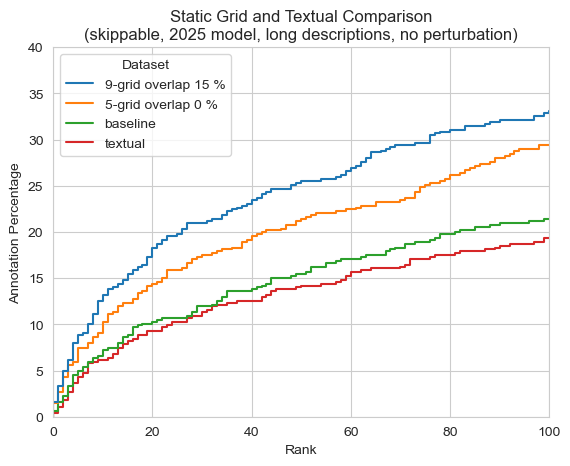

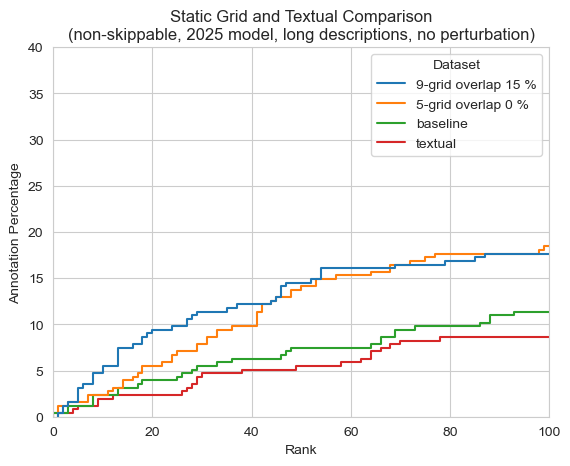

In [36]:
skippable = True
model_year = 2025
description_kind = "long"

def get_static_results(skippable, model_year, description_kind, kinds: list[str], pertubation_factor):
  results = []
  for kind in kinds:
    results.append(get_filtered_ranks(skippable=skippable, model_year=model_year, description_kind=description_kind, kind=kind, pertubation_factor=pertubation_factor))
  return results

filtered_static, filtered_9_grid, filtered_textual, filtered_baseline = get_static_results(True, 2025, "long", ["centerpiece_0", "9_piece_15", "textual_long", "whole"], 0)

# join them together
filtered_static.insert(0, "dataset", ["5-grid overlap 0 %"] * filtered_static.shape[0])
filtered_9_grid.insert(0, "dataset", ["9-grid overlap 15 %"] * filtered_9_grid.shape[0])
filtered_textual.insert(0, "dataset", ["textual"] * filtered_textual.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered = pd.concat([filtered_9_grid, filtered_static, filtered_baseline, filtered_textual])

plot_cumulative("Static Grid and Textual Comparison\n(skippable, 2025 model, long descriptions, no perturbation)", filtered)

filtered_static, filtered_9_grid, filtered_textual, filtered_baseline = get_static_results(False, 2025, "long", ["centerpiece_0", "9_piece_15", "textual_long", "whole"], 0)

# join them together
filtered_static.insert(0, "dataset", ["5-grid overlap 0 %"] * filtered_static.shape[0])
filtered_9_grid.insert(0, "dataset", ["9-grid overlap 15 %"] * filtered_9_grid.shape[0])
filtered_textual.insert(0, "dataset", ["textual"] * filtered_textual.shape[0])
filtered_baseline.insert(0, "dataset", ["baseline"] * filtered_baseline.shape[0])
filtered = pd.concat([filtered_9_grid, filtered_static, filtered_baseline, filtered_textual])

plot_cumulative("Static Grid and Textual Comparison\n(non-skippable, 2025 model, long descriptions, no perturbation)", filtered)


In [31]:
def relabel_static_kind(static):
  static['kind'] = (static['kind'].str
    .replace('centerpiece_0', '5-grid overlap 0 %')
    .replace('centerpiece_10', '5-grid overlap 10 %')
    .replace('centerpiece_20', '5-grid overlap 20 %')
    .replace('centerpiece_30', '5-grid overlap 30 %')
    .replace('centerpiece_40', '5-grid overlap 40 %')
    .replace('9_piece_0', '9-grid overlap 0 %')
    .replace('9_piece_5', '9-grid overlap 5 %')
    .replace('9_piece_10', '9-grid overlap 10 %')
    .replace('9_piece_15', '9-grid overlap 15 %')
    .replace('9_piece_20', '9-grid overlap 20 %')
    .replace('9_piece_25', '9-grid overlap 25 %')
    .replace('9_piece_40', '9-grid overlap 40 %')
    .replace('whole', 'baseline')
    .replace('textual_long', 'textual long')
    .replace('textual_short', 'textual short')
  )

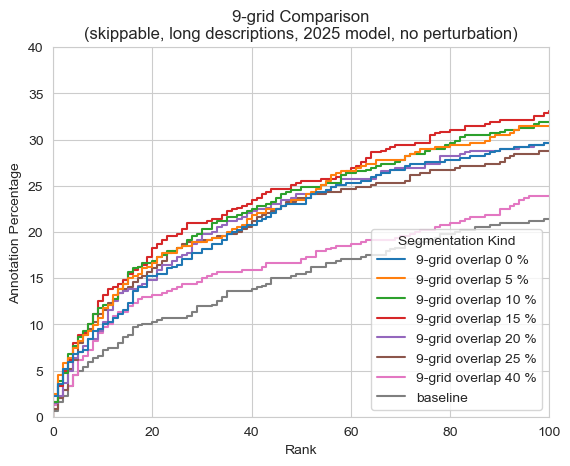

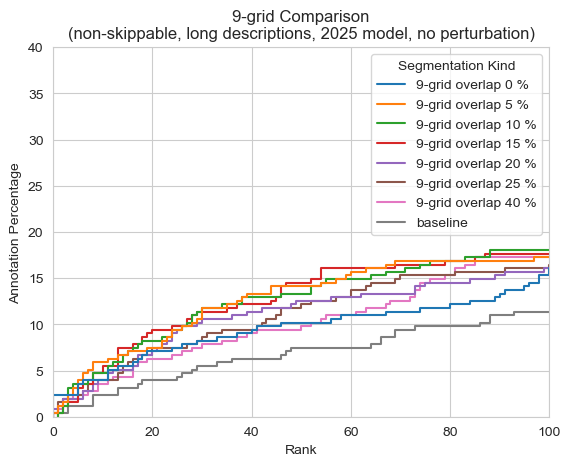

In [32]:
filtered = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", pertubation_factor=0)
filtered = filtered[get_9_piece_filter(filtered) | (filtered["kind"] == "whole")]
relabel_static_kind(filtered)

plot_cumulative("9-grid Comparison\n(skippable, long descriptions, 2025 model, no perturbation)", filtered, key="kind", key_label="Segmentation Kind")

filtered = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", pertubation_factor=0)
filtered = filtered[get_9_piece_filter(filtered) | (filtered["kind"] == "whole")]
relabel_static_kind(filtered)

plot_cumulative("9-grid Comparison\n(non-skippable, long descriptions, 2025 model, no perturbation)", filtered, key="kind", key_label="Segmentation Kind")

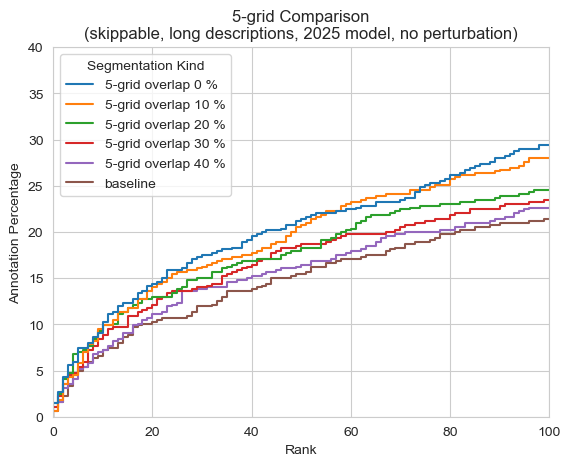

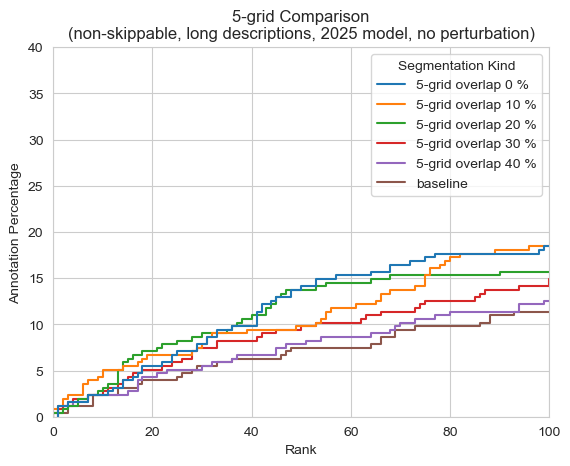

In [33]:
filtered = get_filtered_ranks(skippable=True, model_year=2025, description_kind="long", pertubation_factor=0)
filtered = filtered[get_5_piece_filter(filtered) | (filtered["kind"] == "whole")]
relabel_static_kind(filtered)

plot_cumulative("5-grid Comparison\n(skippable, long descriptions, 2025 model, no perturbation)", filtered, key="kind", key_label="Segmentation Kind")

filtered = get_filtered_ranks(skippable=False, model_year=2025, description_kind="long", pertubation_factor=0)
filtered = filtered[get_5_piece_filter(filtered) | (filtered["kind"] == "whole")]
relabel_static_kind(filtered)

plot_cumulative("5-grid Comparison\n(non-skippable, long descriptions, 2025 model, no perturbation)", filtered, key="kind", key_label="Segmentation Kind")

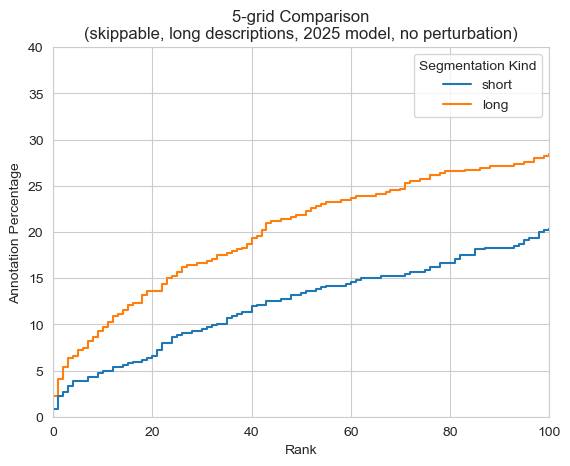

In [34]:
filtered = get_filtered_ranks_dynamic(skippable=True, model_year=2025)

plot_cumulative("5-grid Comparison\n(skippable, long descriptions, 2025 model, no perturbation)", filtered, key="description_kind", key_label="Segmentation Kind")

In [60]:
dynamic_skippable = get_filtered_ranks_dynamic(skippable=True, description_kind="long")
dynamic_non_skippable = get_filtered_ranks_dynamic(skippable=False, description_kind="long")

mean_fallback_non_skippable = dynamic_non_skippable["fallback_count"].mean()
mean_fallback_skippable = dynamic_skippable["fallback_count"].mean()

print(f"Mean dynamic skippable fallback count: {mean_fallback_skippable}, percentage: {mean_fallback_skippable / dataset_size * 100} %")
print(f"Mean dynamic non-skippable fallback count: {mean_fallback_non_skippable}, percentage: {mean_fallback_non_skippable / dataset_size * 100} %")

Mean dynamic skippable fallback count: 22806.8353909465, percentage: 27.051483697999622 %
Mean dynamic non-skippable fallback count: 21417.250980392157, percentage: 25.403279579157807 %
